In [ ]:
!pip install ultralytics -q
!find /kaggle/input -maxdepth 6 -type d | sort
!find /kaggle/input -iname "*.yaml" -o -iname "*.yml"

In [ ]:
!find /kaggle/input/datasets/zymzym/neu-yolo -iname "*.yaml" -o -iname "*.yml" -o -iname "classes.txt" -o -iname "*.names"
!head -5 /kaggle/input/datasets/zymzym/neu-yolo/train/train/labels/$(ls /kaggle/input/datasets/zymzym/neu-yolo/train/train/labels | head -1)
!ls /kaggle/input/datasets/zymzym/neu-yolo/train/train/images | wc -l
!ls /kaggle/input/datasets/zymzym/neu-yolo/valid/valid/images | wc -l

In [ ]:
!cat /kaggle/input/datasets/zymzym/neu-yolo/train/train/labels/*.txt | awk '{print $1}' | sort -n | uniq -c

In [ ]:
data_yaml = """
train: /kaggle/input/datasets/zymzym/neu-yolo/train/train/images
val: /kaggle/input/datasets/zymzym/neu-yolo/valid/valid/images
nc: 6
names: ['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']
"""
with open('/kaggle/working/data.yaml', 'w') as f:
    f.write(data_yaml)

print(open('/kaggle/working/data.yaml').read())

In [ ]:
from ultralytics import YOLO
import time

t0 = time.time()
model_n = YOLO('yolov8n.pt')
model_n.train(data='/kaggle/working/data.yaml', epochs=40, imgsz=640, batch=16,
              workers=2, project='/kaggle/working/runs', name='yolov8n_run',
              patience=15, exist_ok=True)
metrics_n = model_n.val()
print(f"Nano done in {(time.time()-t0)/60:.1f} min")
print(f"P={metrics_n.box.mp:.3f} R={metrics_n.box.mr:.3f} mAP50={metrics_n.box.map50:.3f} mAP50-95={metrics_n.box.map:.3f}")

In [ ]:
t0 = time.time()
model_s = YOLO('yolov8s.pt')
model_s.train(data='/kaggle/working/data.yaml', epochs=40, imgsz=640, batch=16,
              workers=2, project='/kaggle/working/runs', name='yolov8s_run',
              patience=15, exist_ok=True)
metrics_s = model_s.val()
print(f"Small done in {(time.time()-t0)/60:.1f} min")
print(f"P={metrics_s.box.mp:.3f} R={metrics_s.box.mr:.3f} mAP50={metrics_s.box.map50:.3f} mAP50-95={metrics_s.box.map:.3f}")

In [ ]:
t0 = time.time()
model_m = YOLO('yolov8m.pt')
model_m.train(data='/kaggle/working/data.yaml', epochs=40, imgsz=640, batch=16,
              workers=2, project='/kaggle/working/runs', name='yolov8m_run',
              patience=15, exist_ok=True)
metrics_m = model_m.val()
print(f"Medium done in {(time.time()-t0)/60:.1f} min")
print(f"P={metrics_m.box.mp:.3f} R={metrics_m.box.mr:.3f} mAP50={metrics_m.box.map50:.3f} mAP50-95={metrics_m.box.map:.3f}")

In [ ]:
!find /kaggle/working/runs/yolov8m_run -iname "last.pt"
!find /kaggle/working/runs/yolov8m_run -iname "best.pt"

In [ ]:
from ultralytics import YOLO
model_m = YOLO('/kaggle/working/runs/yolov8m_run/weights/last.pt')
model_m.train(resume=True)

In [ ]:
!find /kaggle/working/runs/yolov8n_run -iname "results.csv"

In [ ]:
from ultralytics import YOLO
model_n = YOLO('/kaggle/working/runs/yolov8n_run/weights/best.pt')
m = model_n.val()
print(f"P={m.box.mp:.3f} R={m.box.mr:.3f} mAP50={m.box.map50:.3f} mAP50-95={m.box.map:.3f}")

In [ ]:
from ultralytics import YOLO
model = YOLO('/kaggle/working/runs/yolov8m_run/weights/best.pt')  # or whichever model

for conf_thresh in [0.25, 0.35, 0.45, 0.55, 0.65]:
    m = model.val(conf=conf_thresh)
    print(f"conf={conf_thresh}: P={m.box.mp:.3f} R={m.box.mr:.3f} mAP50={m.box.map50:.3f} mAP50-95={m.box.map:.3f}")

In [ ]:
from ultralytics import YOLO
import time

t0 = time.time()
model_m2 = YOLO('yolov8m.pt')
model_m2.train(
    data='/kaggle/working/data.yaml',
    epochs=120,
    imgsz=640,
    batch=16,
    workers=2,
    patience=30,
    lr0=0.001,
    cls=1.0,
    box=8.0,
    hsv_v=0.6,
    degrees=10.0,
    scale=0.7,
    project='/kaggle/working/runs',
    name='yolov8m_run_v2',
    exist_ok=True
)
metrics_m2 = model_m2.val(conf=0.25)
print(f"Done in {(time.time()-t0)/60:.1f} min")
print(f"P={metrics_m2.box.mp:.3f} R={metrics_m2.box.mr:.3f} mAP50={metrics_m2.box.map50:.3f} mAP50-95={metrics_m2.box.map:.3f}")

In [ ]:
!find /kaggle/working/runs/yolov8m_run_v2 -iname "last.pt"

In [ ]:
from ultralytics import YOLO
model_m2 = YOLO('/kaggle/working/runs/yolov8m_run_v2/weights/last.pt')
model_m2.train(resume=True)

In [ ]:
!find /kaggle/working/runs/yolov8m_run_v2 -iname "last.pt"

In [ ]:
from ultralytics import YOLO
model_m2 = YOLO('/kaggle/working/runs/yolov8m_run_v2/weights/last.pt')
model_m2.train(resume=True)

In [ ]:
from ultralytics import YOLO
model_m2 = YOLO('/kaggle/working/runs/yolov8m_run_v2/weights/last.pt')
model_m2.train(resume=True)

In [ ]:
!find /kaggle/working/runs/yolov8m_run_v2 -iname "last.pt"
!find /kaggle/working/runs/yolov8m_run_v2 -iname "best.pt"

In [ ]:
from ultralytics import YOLO
import time

t0 = time.time()
model_m2 = YOLO('yolov8m.pt')  # fresh pretrained weights, not from any old checkpoint
model_m2.train(
    data='/kaggle/working/data.yaml',   # explicit — avoids any config mixup
    epochs=100,                          # dial back slightly from 120, safer given time lost
    imgsz=640,
    batch=16,
    workers=2,
    patience=25,
    lr0=0.001,
    cls=1.0,
    box=8.0,
    hsv_v=0.6,
    degrees=10.0,
    scale=0.7,
    project='/kaggle/working/runs',
    name='yolov8m_run_v3',              # NEW name — avoids touching the confused v2 folder entirely
    exist_ok=True
)
metrics_m3 = model_m2.val(data='/kaggle/working/data.yaml', conf=0.25)
print(f"Done in {(time.time()-t0)/60:.1f} min")
print(f"P={metrics_m3.box.mp:.3f} R={metrics_m3.box.mr:.3f} mAP50={metrics_m3.box.map50:.3f} mAP50-95={metrics_m3.box.map:.3f}")

In [ ]:
!find /kaggle/working/runs/yolov8m_run_v2 -iname "last.pt"
!find /kaggle/working/runs/yolov8m_run_v2 -iname "best.pt"

In [ ]:
from ultralytics import YOLO
model_m2 = YOLO('/kaggle/working/runs/yolov8m_run_v2/weights/last.pt')
model_m2.train(resume=True)

In [ ]:
import shutil

runs_map = {
    'yolov8n': 'yolov8n_run',
    'yolov8s': 'yolov8s_run',
    'yolov8m_v1': 'yolov8m_run',
}

for label, folder in runs_map.items():
    src = f'/kaggle/working/runs/{folder}'
    dst_zip = f'/kaggle/working/{label}_package'
    shutil.make_archive(dst_zip, 'zip', src)
    print(f"Created {dst_zip}.zip")

In [ ]:
from ultralytics import YOLO
import time

t0 = time.time()
model_l = YOLO('yolov8l.pt')
model_l.train(
    data='/kaggle/working/data.yaml',
    epochs=40,
    imgsz=640,
    batch=8,
    workers=2,
    patience=15,
    project='/kaggle/working/runs',
    name='yolov8l_run',
    exist_ok=True
)
metrics_l = model_l.val(data='/kaggle/working/data.yaml', conf=0.25)
print(f"Large done in {(time.time()-t0)/60:.1f} min")
print(f"P={metrics_l.box.mp:.3f} R={metrics_l.box.mr:.3f} mAP50={metrics_l.box.map50:.3f} mAP50-95={metrics_l.box.map:.3f}")

In [ ]:
!find /kaggle/working/runs/yolov8l_run -iname "last.pt"
!find /kaggle/working/runs/yolov8l_run -iname "best.pt"

In [ ]:
!find /kaggle/working -maxdepth 2

In [1]:
!pip install ultralytics -q

In [2]:
!find /kaggle/input -maxdepth 6 -type d | sort

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/zymzym
/kaggle/input/datasets/zymzym/neu-yolo
/kaggle/input/datasets/zymzym/neu-yolo/train
/kaggle/input/datasets/zymzym/neu-yolo/train/train
/kaggle/input/datasets/zymzym/neu-yolo/train/train/images
/kaggle/input/datasets/zymzym/neu-yolo/train/train/labels
/kaggle/input/datasets/zymzym/neu-yolo/valid
/kaggle/input/datasets/zymzym/neu-yolo/valid/valid
/kaggle/input/datasets/zymzym/neu-yolo/valid/valid/images
/kaggle/input/datasets/zymzym/neu-yolo/valid/valid/labels


In [3]:
data_yaml = """
train: /kaggle/input/datasets/zymzym/neu-yolo/train/train/images
val: /kaggle/input/datasets/zymzym/neu-yolo/valid/valid/images
nc: 6
names: ['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']
"""
with open('/kaggle/working/data.yaml', 'w') as f:
    f.write(data_yaml)
print(open('/kaggle/working/data.yaml').read())


train: /kaggle/input/datasets/zymzym/neu-yolo/train/train/images
val: /kaggle/input/datasets/zymzym/neu-yolo/valid/valid/images
nc: 6
names: ['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']



In [ ]:
from ultralytics import YOLO
import time

t0 = time.time()
model_l = YOLO('yolov8l.pt')
model_l.train(
    data='/kaggle/working/data.yaml',
    epochs=30,
    imgsz=640,
    batch=8,
    workers=2,
    patience=12,
    project='/kaggle/working/runs',
    name='yolov8l_run',
    exist_ok=True
)
metrics_l = model_l.val(data='/kaggle/working/data.yaml', conf=0.25)
print(f"Large done in {(time.time()-t0)/60:.1f} min")
print(f"P={metrics_l.box.mp:.3f} R={metrics_l.box.mr:.3f} mAP50={metrics_l.box.map50:.3f} mAP50-95={metrics_l.box.map:.3f}")

Ultralytics 8.4.90 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8l.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8l_run, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=12,

In [1]:
!pip install ultralytics -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 24.2 MB/s eta 0:00:00a 0:00:01


In [2]:
!find /kaggle/input -maxdepth 6 -type d | sort

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/zymzym
/kaggle/input/datasets/zymzym/neu-yolo
/kaggle/input/datasets/zymzym/neu-yolo/train
/kaggle/input/datasets/zymzym/neu-yolo/train/train
/kaggle/input/datasets/zymzym/neu-yolo/train/train/images
/kaggle/input/datasets/zymzym/neu-yolo/train/train/labels
/kaggle/input/datasets/zymzym/neu-yolo/valid
/kaggle/input/datasets/zymzym/neu-yolo/valid/valid
/kaggle/input/datasets/zymzym/neu-yolo/valid/valid/images
/kaggle/input/datasets/zymzym/neu-yolo/valid/valid/labels


In [3]:
data_yaml = """
train: /kaggle/input/datasets/zymzym/neu-yolo/train/train/images
val: /kaggle/input/datasets/zymzym/neu-yolo/valid/valid/images
nc: 6
names: ['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']
"""
with open('/kaggle/working/data.yaml', 'w') as f:
    f.write(data_yaml)
print(open('/kaggle/working/data.yaml').read())


train: /kaggle/input/datasets/zymzym/neu-yolo/train/train/images
val: /kaggle/input/datasets/zymzym/neu-yolo/valid/valid/images
nc: 6
names: ['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']



In [4]:
from ultralytics import YOLO
import time

t0 = time.time()
model_l = YOLO('yolov8l.pt')
model_l.train(
    data='/kaggle/working/data.yaml',
    epochs=25,
    imgsz=640,
    batch=16,          # increased — risk of OOM on large, watch for crash
    workers=2,
    patience=10,
    project='/kaggle/working/runs',
    name='yolov8l_run',
    exist_ok=True
)
metrics_l = model_l.val(data='/kaggle/working/data.yaml', conf=0.33)  # decreased — will raise recall, LOWER precision
print(f"Large done in {(time.time()-t0)/60:.1f} min")
print(f"P={metrics_l.box.mp:.3f} R={metrics_l.box.mr:.3f} mAP50={metrics_l.box.map50:.3f} mAP50-95={metrics_l.box.map:.3f}")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.90 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=25, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_

In [5]:
from ultralytics import YOLO

model_l = YOLO('/kaggle/working/runs/yolov8l_run/weights/best.pt')
model_l.predict(source='/kaggle/input/datasets/zymzym/neu-yolo/valid/valid/images',
                 save=True, conf=0.25, project='/kaggle/working/runs', name='predict_yolov8l')


image 1/30 /kaggle/input/datasets/zymzym/neu-yolo/valid/valid/images/crazing_1.jpg: 640x640 (no detections), 62.5ms
image 2/30 /kaggle/input/datasets/zymzym/neu-yolo/valid/valid/images/crazing_2.jpg: 640x640 1 crazing, 43.6ms
image 3/30 /kaggle/input/datasets/zymzym/neu-yolo/valid/valid/images/crazing_3.jpg: 640x640 (no detections), 43.7ms
image 4/30 /kaggle/input/datasets/zymzym/neu-yolo/valid/valid/images/crazing_4.jpg: 640x640 2 crazings, 43.6ms
image 5/30 /kaggle/input/datasets/zymzym/neu-yolo/valid/valid/images/crazing_5.jpg: 640x640 1 crazing, 40.9ms
image 6/30 /kaggle/input/datasets/zymzym/neu-yolo/valid/valid/images/inclusion_1.jpg: 640x640 7 inclusions, 39.9ms
image 7/30 /kaggle/input/datasets/zymzym/neu-yolo/valid/valid/images/inclusion_2.jpg: 640x640 3 inclusions, 42.7ms
image 8/30 /kaggle/input/datasets/zymzym/neu-yolo/valid/valid/images/inclusion_3.jpg: 640x640 5 inclusions, 41.5ms
image 9/30 /kaggle/input/datasets/zymzym/neu-yolo/valid/valid/images/inclusion_4.jpg: 640x6

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'crazing', 1: 'inclusion', 2: 'patches', 3: 'pitted_surface', 4: 'rolled-in_scale', 5: 'scratches'}
 obb: None
 orig_img: array([[[185, 185, 185],
         [175, 175, 175],
         [171, 171, 171],
         ...,
         [102, 102, 102],
         [ 89,  89,  89],
         [ 84,  84,  84]],
 
        [[169, 169, 169],
         [171, 171, 171],
         [195, 195, 195],
         ...,
         [ 96,  96,  96],
         [ 89,  89,  89],
         [107, 107, 107]],
 
        [[192, 192, 192],
         [222, 222, 222],
         [200, 200, 200],
         ...,
         [ 83,  83,  83],
         [118, 118, 118],
         [112, 112, 112]],
 
        ...,
 
        [[253, 253, 253],
         [219, 219, 219],
         [194, 194, 194],
         ...,
         [164, 164, 164],
         [132, 132, 132],
         [123, 123, 123]],
 
        [[255, 255, 

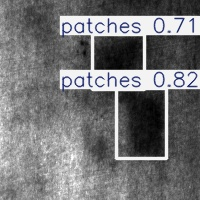

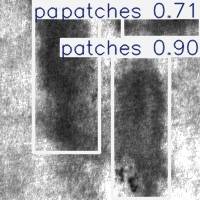

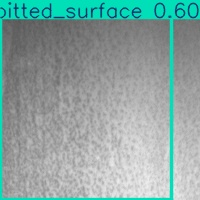

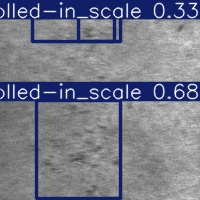

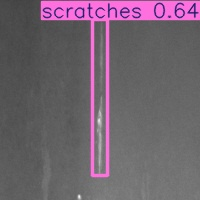

In [6]:
from IPython.display import Image, display
import os

pred_folder = '/kaggle/working/runs/predict_yolov8l'
images = os.listdir(pred_folder)[:5]  # show first 5
for img in images:
    display(Image(f'{pred_folder}/{img}'))

In [7]:
import shutil
shutil.make_archive('/kaggle/working/yolov8l_predictions', 'zip', '/kaggle/working/runs/predict_yolov8l')

'/kaggle/working/yolov8l_predictions.zip'

In [8]:
!find /kaggle/working/runs/yolov8l_run -iname "best.pt"

/kaggle/working/runs/yolov8l_run/weights/best.pt


In [9]:
import shutil
shutil.make_archive('/kaggle/working/yolov8l_package', 'zip', '/kaggle/working/runs/yolov8l_run')
print("Created yolov8l_package.zip")

Created yolov8l_package.zip


In [10]:
from ultralytics import YOLO
model = YOLO('/kaggle/working/runs/yolov8n_run/weights/best.pt')
print("Model loaded successfully:", model)

FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/working/runs/yolov8n_run/weights/best.pt'

In [11]:
from ultralytics import YOLO
model = YOLO('/kaggle/working/runs/yolov8l_run/weights/best.pt')
print("Large model loaded successfully")

Large model loaded successfully


In [1]:
metrics_l = model_l.val(data='/kaggle/working/data.yaml', conf=0.25)
print(f"P={metrics_l.box.mp:.3f} R={metrics_l.box.mr:.3f} mAP50={metrics_l.box.map50:.3f} mAP50-95={metrics_l.box.map:.3f}")

NameError: name 'model_l' is not defined

In [2]:
from ultralytics import YOLO

model_l = YOLO('/kaggle/working/runs/yolov8l_run/weights/best.pt')
metrics_l = model_l.val(data='/kaggle/working/data.yaml', conf=0.25)
print(f"P={metrics_l.box.mp:.3f} R={metrics_l.box.mr:.3f} mAP50={metrics_l.box.map50:.3f} mAP50-95={metrics_l.box.map:.3f}")

ModuleNotFoundError: No module named 'ultralytics'

In [3]:
!pip install ultralytics -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 23.2 MB/s eta 0:00:00a 0:00:01


In [4]:
from ultralytics import YOLO

model_l = YOLO('/kaggle/working/runs/yolov8l_run/weights/best.pt')
metrics_l = model_l.val(data='/kaggle/working/data.yaml', conf=0.25)
print(f"P={metrics_l.box.mp:.3f} R={metrics_l.box.mr:.3f} mAP50={metrics_l.box.map50:.3f} mAP50-95={metrics_l.box.map:.3f}")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/working/runs/yolov8l_run/weights/best.pt'

In [1]:
!pip install ultralytics -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 29.2 MB/s eta 0:00:0000:01


In [2]:
from ultralytics import YOLO
model_l = YOLO('/path/to/your/uploaded/best.pt')  # upload best.pt as input first, or place in /kaggle/working
metrics_l = model_l.val(data='/kaggle/working/data.yaml', conf=0.25)
print(f"P={metrics_l.box.mp:.3f} R={metrics_l.box.mr:.3f} mAP50={metrics_l.box.map50:.3f} mAP50-95={metrics_l.box.map:.3f}")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


FileNotFoundError: [Errno 2] No such file or directory: '/path/to/your/uploaded/best.pt'

In [3]:
!find /kaggle/input -iname "best.pt"

In [4]:
from ultralytics import YOLO

model_l = YOLO('/kaggle/input/best-pt-large/best.pt')  # replace with your actual printed path
metrics_l = model_l.val(data='/kaggle/working/data.yaml', conf=0.25)
print(f"P={metrics_l.box.mp:.3f} R={metrics_l.box.mr:.3f} mAP50={metrics_l.box.map50:.3f} mAP50-95={metrics_l.box.map:.3f}")

FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/input/best-pt-large/best.pt'

In [5]:
!find /kaggle/input -iname "best.pt"

In [6]:
!find /kaggle/input -iname "best.pt"

/kaggle/input/models/swayamsundar/best-pt/other/default/1/best.pt


In [8]:
data_yaml = """
train: /kaggle/input/datasets/zymzym/neu-yolo/train/train/images
val: /kaggle/input/datasets/zymzym/neu-yolo/valid/valid/images
nc: 6
names: ['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']
"""
with open('/kaggle/working/data.yaml', 'w') as f:
    f.write(data_yaml)|

SyntaxError: invalid syntax (2405748656.py, line 8)

In [10]:
data_yaml = """
train: /kaggle/input/datasets/zymzym/neu-yolo/train/train/images
val: /kaggle/input/datasets/zymzym/neu-yolo/valid/valid/images
nc: 6
names: ['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']
"""
with open('/kaggle/working/data.yaml', 'w') as f:
    f.write(data_yaml)

In [11]:
!pip install ultralytics -q
from ultralytics import YOLO

model_l = YOLO('PASTE_THE_EXACT_PATH_FROM_STEP_3_HERE')
metrics_l = model_l.val(data='/kaggle/working/data.yaml', conf=0.25)
print(f"P={metrics_l.box.mp:.3f} R={metrics_l.box.mr:.3f} mAP50={metrics_l.box.map50:.3f} mAP50-95={metrics_l.box.map:.3f}")

FileNotFoundError: 'PASTE_THE_EXACT_PATH_FROM_STEP_3_HERE' does not exist

In [12]:
!find /kaggle/input -iname "best.pt"

/kaggle/input/models/swayamsundar/best-pt/other/default/1/best.pt


In [13]:
from ultralytics import YOLO

model_l = YOLO('/kaggle/input/models/swayamsundar/best-pt/other/default/1/best.pt')
metrics_l = model_l.val(data='/kaggle/working/data.yaml', conf=0.25)
print(f"P={metrics_l.box.mp:.3f} R={metrics_l.box.mr:.3f} mAP50={metrics_l.box.map50:.3f} mAP50-95={metrics_l.box.map:.3f}")

Ultralytics 8.4.90 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
Model summary (fused): 113 layers, 43,611,234 parameters, 0 gradients, 164.8 GFLOPs
WARNING ⚠️ val: Slow image access detected (ping: 0.7±0.1 ms, read: 2.0±1.0 MB/s, size: 13.5 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips/
val: Scanning /kaggle/input/datasets/zymzym/neu-yolo/valid/valid/labels... 30 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 30/30 167.4it/s 0.2s.5s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/zymzym/neu-yolo/valid/valid is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 1.3s/it 2.7s6.5s
                   all         30         64      0.708      0.697      0.645      0.416
               crazing          5          8      0.333      0.125     0.0417      0.025
             inclusi